# Channels in the two Cellpose ops

Colour images are the one place `cellpose` (CPSAM) and `cellpose3` differ most.
This notebook runs both on the same RGB image, built-in models only.

| op | how it takes colour |
| --- | --- |
| `cellpose` | pass the channels straight through, or `collapse_channels=True` to average them to grey |
| `cellpose3` | name which colour is cytoplasm and which is nuclei, or leave `grayscale` to average them |

## Setup

Cellpose is not installed here -- skop builds an environment per op on first
call. See `cellpose_mixed.ipynb` for the install and environment details.

The image lives under `test_images/`, two directories up, and is gitignored;
get it from [dropbox](https://www.dropbox.com/scl/fo/6tmw90z3g6spzkznn897h/AEI8jCt1dUtjTXhNerM5P3A?rlkey=4i2twwhfaaaj1xj4hp6rk73yj&st=yzeedova&dl=0).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import tifffile
from skimage.color import label2rgb

import skop
from skop.ops.segment import cellpose, cellpose3
from skop.ops.segment.cellpose3 import (
    CytoplasmChannel,
    NucleusChannel,
    PretrainedModel,
)

plt.rcParams["figure.dpi"] = 72

DATA = Path("../../test_images/segmentation/tough_cellpose").resolve()

## The image

Cells with long thin protrusions. RGB: cells **green**, nuclei **blue**, red empty.

(750, 756, 3) uint16, range 0-65535


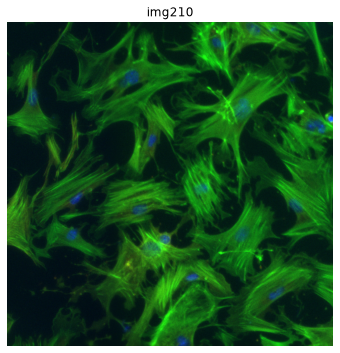

In [2]:
image = tifffile.imread(DATA / "img210.tif")
print(f"{image.shape} {image.dtype}, range {image.min()}-{image.max()}")

# Grey backdrop for the mask overlays below.
gray = image.mean(axis=-1)
gray = gray / gray.max()

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(image / image.max())
ax.set_title("img210")
ax.axis("off")
fig.tight_layout()

In [3]:
runner = skop.Runner()

_last = None


def on_build(title, current, maximum):
    global _last
    if title != _last:
        _last = title
        print("  [build]", title)


runner.subscribe_build_progress(on_build)

## Two networks, two channel APIs

**CPSAM** takes 1-3 channels in any order and works out what to do with them.
Nothing to name. So the op passes the image through as it is, and
`collapse_channels=True` is the opt-out: average the colours to grey first.

**Cellpose 3** takes exactly two input planes, cytoplasm and optional nuclei.
So it must be told which colour is which -- `cytoplasm_channel=green`,
`nucleus_channel=blue`. `grayscale` is the default and means: average the
colours into the cytoplasm plane, no nuclei plane.

Same word, different reason. `cellpose3` collapses to grey because it has only
two slots to fill; `cellpose` collapses only if you ask it to.

Two more things `cellpose3` gets wrong quietly if you mix them up:

- Naming a colour without a colour axis has nothing to pick from. Cellpose's
  reshape short-circuits on single-channel input and never reads `channels`.
- `nucleus_channel` is ignored when `cytoplasm_channel` is `grayscale` --
  Cellpose reads the pair, and a grey first slot drops the second.

The options:

In [4]:
print("cytoplasm  ", [c.value for c in CytoplasmChannel])
print("nuclei     ", [c.value for c in NucleusChannel])
print("cp3 models ", [m.value for m in PretrainedModel])

cytoplasm   ['grayscale', 'red', 'green', 'blue']
nuclei      ['none', 'red', 'green', 'blue']
cp3 models  ['cyto3', 'nuclei', 'bact_phase_cp3', 'bact_fluor_cp3', 'yeast_PhC_cp3', 'yeast_BF_cp3', 'tissuenet_cp3', 'livecell_cp3', 'deepbacs_cp3']


# CPSAM: RGB vs grey

Built-in CPSAM, `flow_threshold=2.0` and `niter=2000` to keep the protrusions
(see `cellpose_mixed.ipynb` for why). Only `collapse_channels` changes.

In [5]:
# Default: the three channels go to CPSAM as they are.
labels_cpsam_rgb = runner.run(
    cellpose,
    image=image,
    niter=2000,
    flow_threshold=2.0,
)
print("cpsam rgb   ", labels_cpsam_rgb.max(), "objects")

cpsam rgb    39 objects


In [6]:
# Averaged to one plane first -- the empty red channel dilutes the signal.
labels_cpsam_gray = runner.run(
    cellpose,
    image=image,
    niter=2000,
    flow_threshold=2.0,
    collapse_channels=True,
)
print("cpsam grey  ", labels_cpsam_gray.max(), "objects")

cpsam grey   48 objects


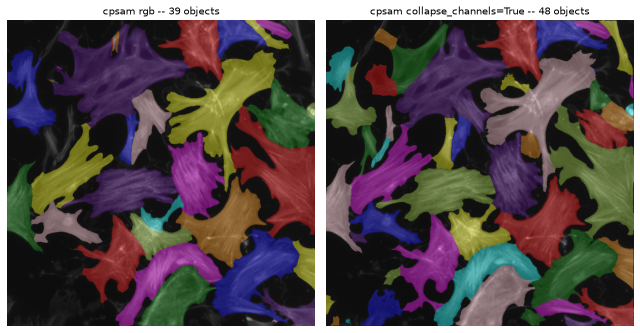

In [7]:
def show(ax, labels, title):
    ax.imshow(label2rgb(labels, image=gray, bg_label=0, alpha=0.35))
    ax.set_title(f"{title} -- {labels.max()} objects", fontsize=10)
    ax.axis("off")


fig, axes = plt.subplots(1, 2, figsize=(9, 5))
show(axes[0], labels_cpsam_rgb, "cpsam rgb")
show(axes[1], labels_cpsam_gray, "cpsam collapse_channels=True")
fig.tight_layout()

# Cellpose 3: named channels vs grey

cyto3, `diameter=150` and `flow_threshold=2.0`. Only the channel settings change.

In [8]:
# Cells green, nuclei blue -- the nuclear plane helps split touching cells.
labels_cp3_named = runner.run(
    cellpose3,
    image=image,
    model=PretrainedModel.cyto3,
    diameter=150.0,
    flow_threshold=2.0,
    cytoplasm_channel=CytoplasmChannel.green,
    nucleus_channel=NucleusChannel.blue,
)
print("cyto3 named ", labels_cp3_named.max(), "objects")

cyto3 named  53 objects


In [12]:
# Cells green, nuclei blue -- the nuclear plane helps split touching cells.
labels_cp3_no_nuclei = runner.run(
    cellpose3,
    image=image,
    model=PretrainedModel.cyto3,
    diameter=150.0,
    flow_threshold=2.0,
    cytoplasm_channel=CytoplasmChannel.green,
)
print("cyto3 no nuclei ", labels_cp3_no_nuclei.max(), "objects")

cyto3 no nuclei  71 objects


In [10]:
# Default: colours averaged into one cytoplasm plane, no nuclei.
labels_cp3_gray = runner.run(
    cellpose3,
    image=image,
    model=PretrainedModel.cyto3,
    diameter=150.0,
    flow_threshold=2.0,
    cytoplasm_channel=CytoplasmChannel.grayscale,
)
print("cyto3 grey  ", labels_cp3_gray.max(), "objects")

cyto3 grey   80 objects


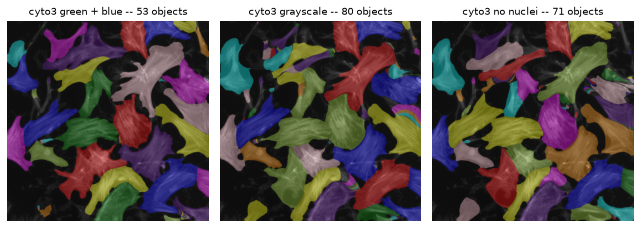

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(9, 5))
show(axes[0], labels_cp3_named, "cyto3 green + blue")
show(axes[1], labels_cp3_gray, "cyto3 grayscale")
show(axes[2], labels_cp3_no_nuclei, "cyto3 no nuclei")
fig.tight_layout()

In [14]:
import napari

viewer = napari.Viewer()
viewer.add_image(image, name="img210")
viewer.add_labels(labels_cpsam_rgb, name="cpsam rgb")
viewer.add_labels(labels_cpsam_gray, name="cpsam collapse_channels=True")
viewer.add_labels(labels_cp3_named, name="cyto3 green + blue")
viewer.add_labels(labels_cp3_gray, name="cyto3 grayscale")
viewer.add_labels(labels_cp3_no_nuclei, name="cyto3 no nuclei")

/home/bnorthan/code/i2k/tnia/napari-ai-lab/pixi/pytorch_napari/.pixi/envs/default/lib/python3.12/site-packages/napari/_qt/qt_event_loop.py:50: UserWarning: System theme detection requires a Qt6 backend. Please switch to PyQt6 or PySide6 to use it.
  theme_type=get_system_theme(),
/home/bnorthan/code/i2k/tnia/napari-ai-lab/pixi/pytorch_napari/.pixi/envs/default/lib/python3.12/site-packages/napari/_qt/qt_event_loop.py:50: UserWarning: System theme detection requires a Qt6 backend. Please switch to PyQt6 or PySide6 to use it.
  theme_type=get_system_theme(),


<Labels layer 'cyto3 no nuclei' at 0x74a90de128d0>

## Summary

| you want | `cellpose` (CPSAM) | `cellpose3` |
| --- | --- | --- |
| use the colours | default | `cytoplasm_channel=` and `nucleus_channel=` |
| one grey plane | `collapse_channels=True` | default |
| a nuclear stain to help | not a separate input | `nucleus_channel=` |

In [ ]:
runner.close()